In [175]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [176]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder


In [177]:
ratings_path = "/content/drive/MyDrive/UMD/DATA606/p2/data/Ratings.csv"
books_path   = "/content/drive/MyDrive/UMD/DATA606/p2/data/Books.csv"
users_path   = "/content/drive/MyDrive/UMD/DATA606/p2/data/Users.csv"

In [178]:
ratings = pd.read_csv(ratings_path)
books   = pd.read_csv(books_path)
users   = pd.read_csv(users_path)

print(f"{len(ratings):,} ratings  |  {len(books):,} books  |  {len(users):,} users")
ratings.head()

<ipython-input-178-3e52487c111a>:2: DtypeWarning:

Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.



1,149,780 ratings  |  271,360 books  |  278,858 users


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [179]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [180]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [181]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [182]:
books.shape, users.shape, ratings.shape

((271360, 8), (278858, 3), (1149780, 3))

In [183]:
ratings_books = pd.merge(ratings, books, on='ISBN')
ratings_books_users = pd.merge(ratings_books, users, on='User-ID')
ratings_books_users.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",NaN
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0


In [184]:
ratings_books_users.shape

(1031136, 12)

In [185]:
ratings_books_users.duplicated().sum()


np.int64(0)

In [186]:
ratings_books_users.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,4


Missing `Age` value percentage - `"27%"`

Dropping it because majority in it is missing.

In [187]:
277835/1031136

0.2694455435558452

In [188]:
ratings_books_users.drop(columns='Age', inplace=True)

In [189]:

# Display rows with NaN values in specific columns
columns_to_check = ['Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Location'] # Replace with your column names
rows_with_nan = ratings_books_users[ratings_books_users[columns_to_check].isnull().any(axis=1)]
rows_with_nan


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location
244331,63714,0751352497,10,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...,"milton keynes, england, united kingdom"
368342,98391,193169656X,9,Tyrant Moon,Elaine Corvidae,2002,NaN,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...,"morrow, georgia, usa"
368351,98391,1931696993,9,Finders Keepers,Linnea Sinclair,2001,NaN,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...,"morrow, georgia, usa"
369234,98647,9627982032,8,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...,"selayang, selangor, malaysia"


In [190]:
#Dropping them for need
ratings_books_users.dropna(inplace=True)
ratings_books_users.shape

(1031128, 11)

In [191]:
ratings_books_users.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1031128 entries, 0 to 1031135
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   User-ID              1031128 non-null  int64 
 1   ISBN                 1031128 non-null  object
 2   Book-Rating          1031128 non-null  int64 
 3   Book-Title           1031128 non-null  object
 4   Book-Author          1031128 non-null  object
 5   Year-Of-Publication  1031128 non-null  object
 6   Publisher            1031128 non-null  object
 7   Image-URL-S          1031128 non-null  object
 8   Image-URL-M          1031128 non-null  object
 9   Image-URL-L          1031128 non-null  object
 10  Location             1031128 non-null  object
dtypes: int64(2), object(9)
memory usage: 94.4+ MB


In [192]:
# convert Year-Of-Publication to int for ease
ratings_books_users['Year-Of-Publication'] = ratings_books_users['Year-Of-Publication'].astype(int)
# convert book rating column to int
ratings_books_users['Book-Rating'] = ratings_books_users['Book-Rating'].astype(int)

In [193]:
ratings_books_users.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa"
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa"
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia"
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia"
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia"


In [194]:
ratings_books_users['Year-Of-Publication'].value_counts().sort_index()

,count
Year-Of-Publication,
0,14009
1376,1
1378,1
1806,1
1897,1
...,...
2026,5
2030,32
2037,1


In [195]:
# Weeding out the 0 as Year-Of-Publication and there are future years in it mostly false assumed
ratings_books_users = ratings_books_users[ratings_books_users['Year-Of-Publication'] != 0]
ratings_books_users.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa"
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa"
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia"
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia"
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia"


In [196]:
ratings_books_users.shape

(1017119, 11)

In [197]:
ratings_books_users = ratings_books_users[ratings_books_users['Year-Of-Publication'] <= 2025]
ratings_books_users.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa"
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa"
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia"
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia"
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia"


In [198]:
ratings_books_users.shape

(1017066, 11)

In [199]:
ratings_books_users.describe()

,User-ID,Book-Rating,Year-Of-Publication
count,1.017066e+06,1.017066e+06,1.017066e+06
mean,1.406404e+05,2.834958e+00,1.995301e+03
std,8.050846e+04,3.853146e+00,7.358670e+00
min,2.000000e+00,0.000000e+00,1.376000e+03
25%,7.041500e+04,0.000000e+00,1.992000e+03
50%,1.414325e+05,0.000000e+00,1.997000e+03
75%,2.114260e+05,7.000000e+00,2.001000e+03
max,2.788540e+05,1.000000e+01,2.024000e+03


In [200]:
# Count of unique values in object columns
for col in ['Publisher', 'Location', 'Book-Author']:
  print(f'Unique values in {col}: {ratings_books_users[col].nunique()}')


Unique values in Publisher: 16315
Unique values in Location: 22094
Unique values in Book-Author: 100238


In [201]:
n_users = ratings_books_users['User-ID'].nunique()
n_books = ratings_books_users['Book-Title'].nunique()
print(f'Number of unique users: {n_users} and unique books: {n_books}')

Number of unique users: 90679 and unique books: 237448


In [202]:
avg_ratings_per_user = ratings_books_users.groupby('User-ID')['Book-Rating'].count().mean()
print(f'Mean ratings per user: {avg_ratings_per_user:.2f}')

Mean ratings per user: 11.22


In [203]:
# Find the average number of ratings per book
avg_ratings_per_book = ratings_books_users.groupby('Book-Title')['Book-Rating'].count().mean()
print(f'Mean ratings per book: {avg_ratings_per_book:.2f}')

Mean ratings per book: 4.28


In [204]:
n_locations = ratings_books_users['Location'].unique()
print(f'Unique locations: {n_locations}')

Unique locations: ['tyler, texas, usa' 'seattle, washington, usa'
 'h, new south wales, australia' ... 'reeves, louisiana, usa'
 'wakeman, ohio, usa' 'mannington, west virginia, usa']


In [205]:
# Split the location into seperate columns
split_locations = ratings_books_users['Location'].str.split(',', expand=True)

ratings_books_users['City'] = split_locations[0]
ratings_books_users['State'] = split_locations[1]
ratings_books_users['Country'] = split_locations[2]


In [208]:
def preprocess_and_get_unique(column):
    """
    Preprocesses a column (e.g., 'Country', 'State', 'City') by lowercasing,
    removing non-alphanumeric characters and spaces, and returns unique values.
    Also stores the mapping between original and processed values.

    Args:
        column (pd.Series): The column to preprocess.

    Returns:
        tuple: A tuple containing a list of unique preprocessed values and a dictionary mapping
               original values to their preprocessed versions.
    """
    unique_values = column.unique()
    preprocessed_values = []
    mapping = {}

    for value in unique_values:
        if isinstance(value, str):
            processed_value = value.lower().strip()
            processed_value = ''.join(e for e in processed_value if e.isalnum() or e.isspace())

            if processed_value not in preprocessed_values:
                preprocessed_values.append(processed_value)

            mapping[value] = processed_value  # Store the mapping

    return preprocessed_values, mapping

unique_countries_processed, country_mapping = preprocess_and_get_unique(ratings_books_users['Country'])
unique_states_processed, state_mapping = preprocess_and_get_unique(ratings_books_users['State'])
unique_cities_processed, city_mapping = preprocess_and_get_unique(ratings_books_users['City'])
# print(f"Unique preprocessed cities: {unique_cities_processed}")
len(unique_cities_processed), len(unique_states_processed), len(unique_countries_processed)


(14309, 1827, 367)

In [209]:

def replace_with_mapping(df, column, mapping):
    """Replaces values in a DataFrame column based on a provided mapping.

    Args:
        df: The DataFrame.
        column: The column to modify.
        mapping: A dictionary where keys are original values and values are replacements.
    """
    df[column] = df[column].map(mapping).fillna(df[column])

replace_with_mapping(ratings_books_users, 'Country', country_mapping)
replace_with_mapping(ratings_books_users, 'State', state_mapping)
replace_with_mapping(ratings_books_users, 'City', city_mapping)


In [210]:
# prompt: drop the location from dataframe

ratings_books_users.drop(columns='Location', inplace=True)


In [211]:
ratings_books_users.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,City,State,Country
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,tyler,texas,usa
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,seattle,washington,usa
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,h,new south wales,australia
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,rijeka,na,croatia
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,rijeka,na,croatia


In [212]:

# Initialize LabelEncoders
publisher_encoder = LabelEncoder()
author_encoder = LabelEncoder()
city_encoder = LabelEncoder()
state_encoder = LabelEncoder()
country_encoder = LabelEncoder()

# Fit and transform the columns
ratings_books_users['Publisher'] = publisher_encoder.fit_transform(ratings_books_users['Publisher'])
ratings_books_users['Book-Author'] = author_encoder.fit_transform(ratings_books_users['Book-Author'])
ratings_books_users['City'] = city_encoder.fit_transform(ratings_books_users['City'])
ratings_books_users['State'] = state_encoder.fit_transform(ratings_books_users['State'])
ratings_books_users['Country'] = country_encoder.fit_transform(ratings_books_users['Country'])

ratings_books_users.head()


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,City,State,Country
0,276725,034545104X,0,Flesh Tones: A Novel,60834,2002,1360,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,12921,1584,338
1,276726,0155061224,5,Rites of Passage,51119,2001,6721,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,11374,1733,338
2,276727,0446520802,0,The Notebook,71424,1996,15468,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,5124,1070,26
3,276729,052165615X,3,Help!: Level 1,76950,1999,2515,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,10587,1037,79
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,90609,2001,2515,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,10587,1037,79


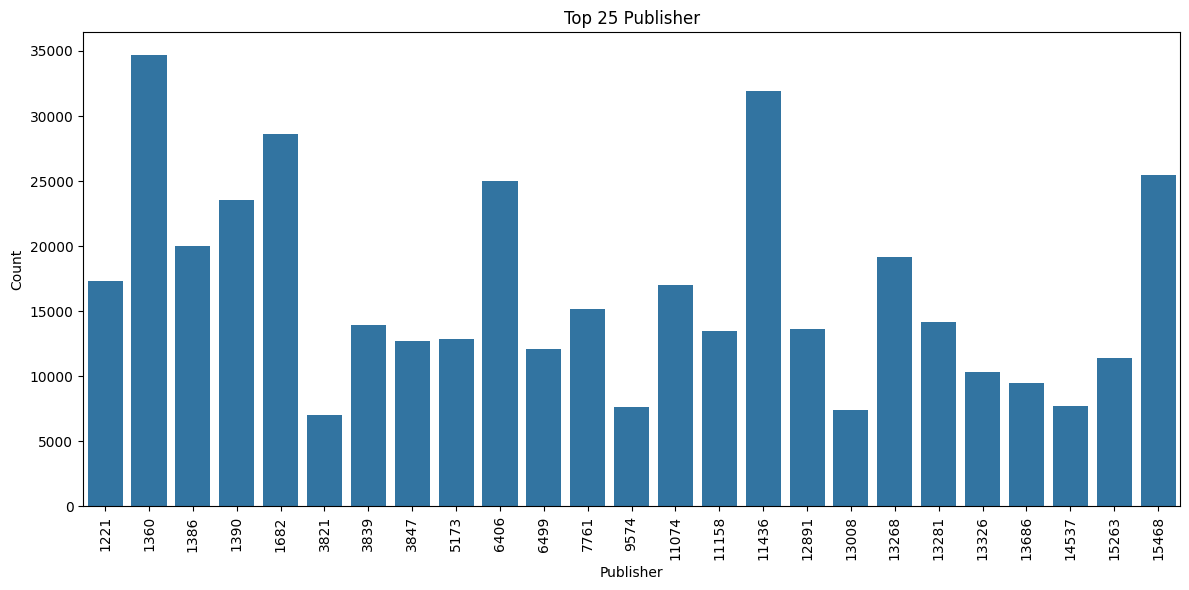

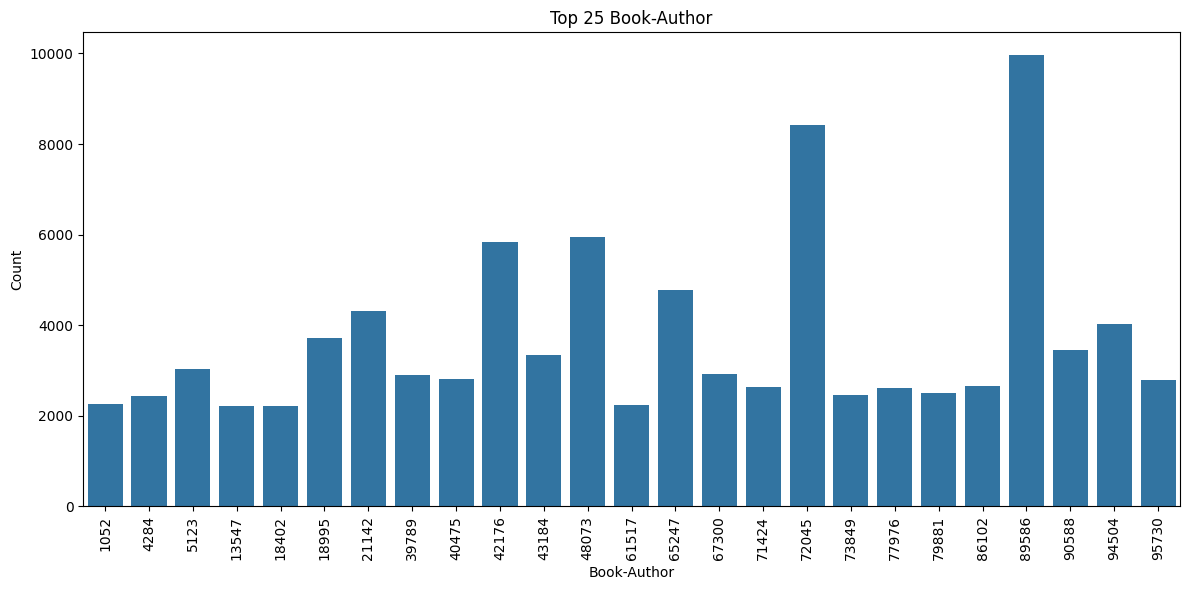

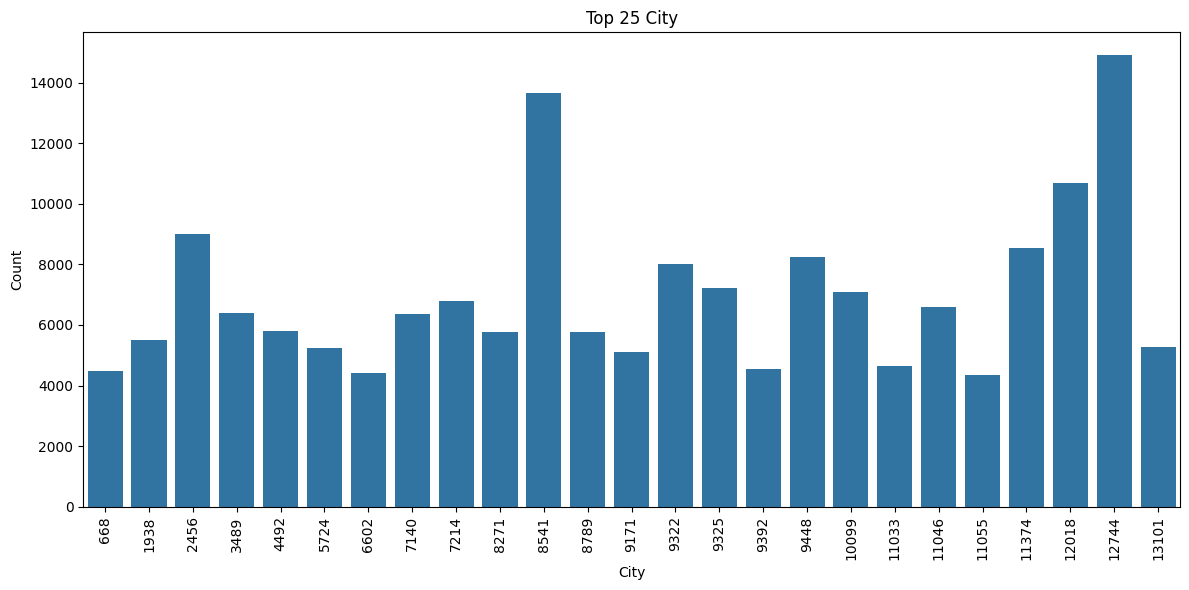

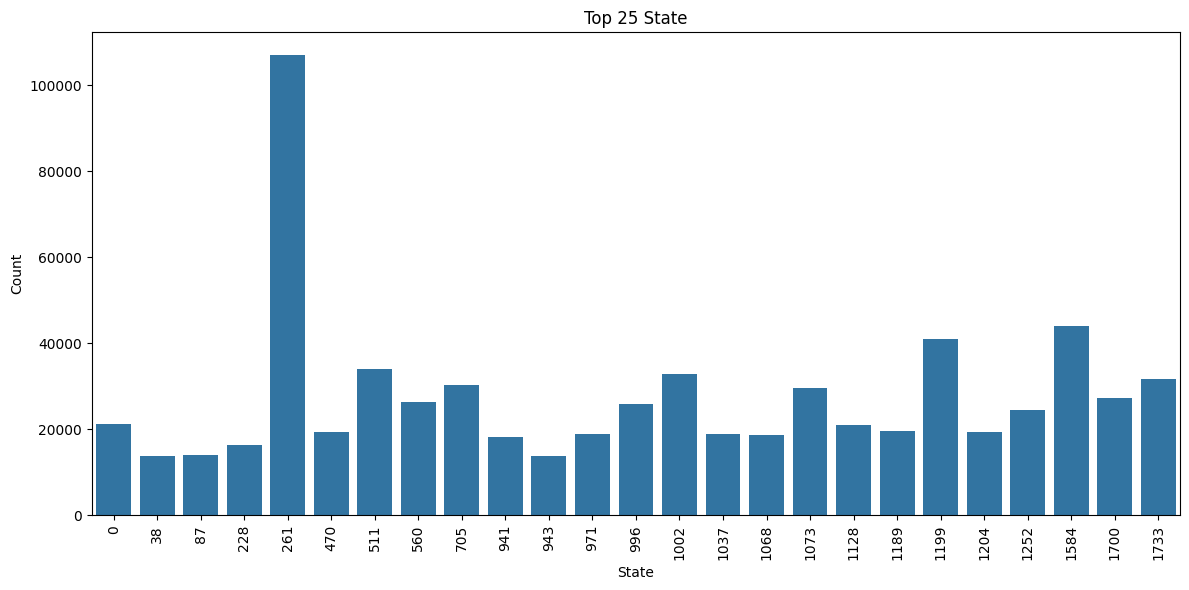

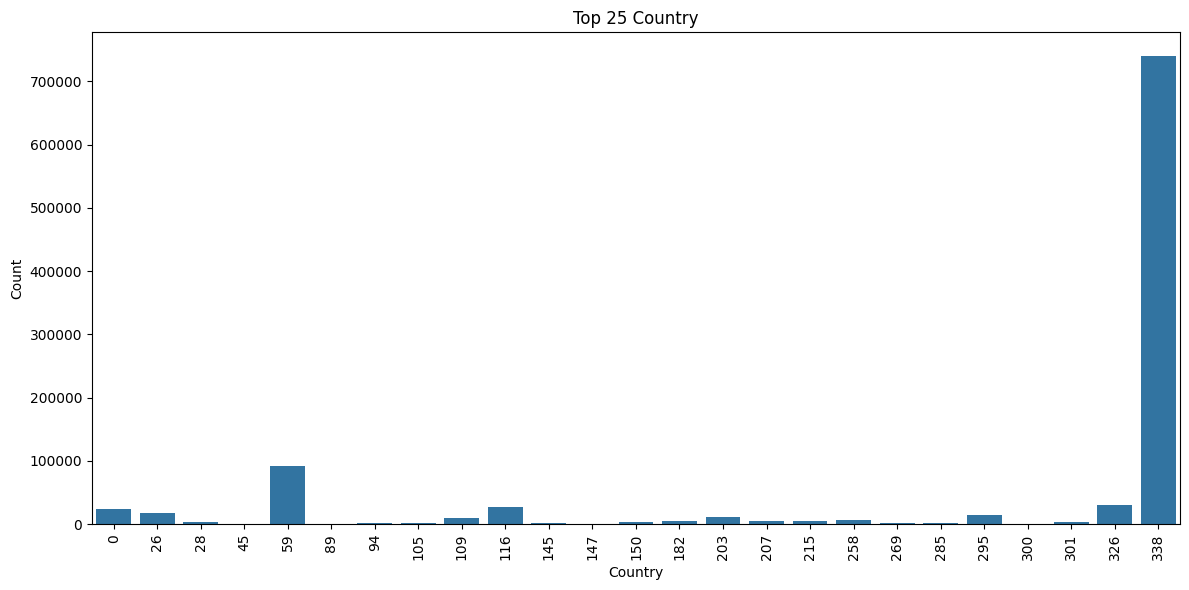

In [213]:
# prompt: I need plots for these categories from for top 25 each columns seperately

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'ratings_books_users' DataFrame is already loaded and preprocessed as in your provided code.

def plot_top_categories(df, column_name, top_n=25):
  """Plots the top N categories for a given column."""
  top_categories = df[column_name].value_counts().nlargest(top_n)
  plt.figure(figsize=(12, 6))
  sns.barplot(x=top_categories.index, y=top_categories.values)
  plt.title(f'Top {top_n} {column_name}')
  plt.xlabel(column_name)
  plt.ylabel('Count')
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()


# Example usage for different columns
columns_to_plot = ['Publisher', 'Book-Author', 'City', 'State', 'Country']
for col in columns_to_plot:
  plot_top_categories(ratings_books_users, col)


In [214]:
import pickle

# Save the encoder mappings to separate files
with open('/content/drive/MyDrive/UMD/DATA606/p2/preprocessed/publisher_encoder.pkl', 'wb') as f:
    pickle.dump(publisher_encoder, f)
with open('/content/drive/MyDrive/UMD/DATA606/p2/preprocessed/author_encoder.pkl', 'wb') as f:
    pickle.dump(author_encoder, f)
with open('/content/drive/MyDrive/UMD/DATA606/p2/preprocessed/city_encoder.pkl', 'wb') as f:
    pickle.dump(city_encoder, f)
with open('/content/drive/MyDrive/UMD/DATA606/p2/preprocessed/state_encoder.pkl', 'wb') as f:
    pickle.dump(state_encoder, f)
with open('/content/drive/MyDrive/UMD/DATA606/p2/preprocessed/country_encoder.pkl', 'wb') as f:
    pickle.dump(country_encoder, f)


In [215]:

# Save the DataFrame to a pickle file
ratings_books_users.to_csv('/content/drive/MyDrive/UMD/DATA606/p2/preprocessed/ratings_books_users.csv', index=False)


In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from ipywidgets import interact, widgets

# ... (Assuming ratings_books_users and country_encoder are loaded)

# Reverse the country mapping beforehand
reversed_country_mapping = {country_encoder.classes_[i]: i for i in range(len(country_encoder.classes_))}

# Function to plot top books by country
def plot_country_books(country_name):
    # Get the encoded country code
    country_code = reversed_country_mapping[country_name]

    # Filter data for the selected country
    country_data = ratings_books_users[ratings_books_users['Country'] == country_code]

    # Get the top 5 books
    top_books = country_data['Book-Title'].value_counts().head(5)

    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_books.index, y=top_books.values)
    plt.title(f'Top 5 Books in {country_name}')
    plt.xlabel('Book Title')
    plt.ylabel('Number of Ratings')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Create an interactive widget
country_names = list(reversed_country_mapping.keys())
interact(plot_country_books, country_name=widgets.Dropdown(options=country_names, description='Country:'))

interactive(children=(Dropdown(description='Country:', options=('', '61 men', 'aberdeenshire', 'afghanistan', …

<function __main__.plot_country_books(country_name)>

In [218]:
reversed_country_mapping = {country_encoder.classes_[i]: i for i in range(len(country_encoder.classes_))}

country_book_counts = ratings_books_users.groupby('Country')['Book-Title'].nunique().reset_index()  # Count unique book titles
country_book_counts['Country'] = country_book_counts['Country'].map({v: k for k, v in reversed_country_mapping.items()})

# Function to get top 5 books for a country
def get_top_books(country_name):
    country_code = reversed_country_mapping[country_name]
    country_data = ratings_books_users[ratings_books_users['Country'] == country_code]
    top_books = country_data['Book-Title'].value_counts().head(5).index.tolist()
    return "<br>".join(top_books)  # Join book titles with line breaks for hover text

# Add top books as a column for hover data
country_book_counts['Top Books'] = country_book_counts['Country'].apply(get_top_books)

# Create the choropleth map
fig = px.choropleth(
    country_book_counts,
    locations='Country',
    locationmode='country names',
    color='Book-Title',
    color_continuous_scale='Viridis',
    title='Number of Unique Book Titles by Country',
    hover_name='Country',
    hover_data={'Book-Title': True, 'Top Books': True},  # Include top books in hover data
    labels={'Book-Title': 'Number of Book Titles'},  # Update colorbar label
    range_color=[0, 150],
)

fig.show()

In [219]:
ratings_books_users

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,City,State,Country
0,276725,034545104X,0,Flesh Tones: A Novel,60834,2002,1360,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,12921,1584,338
1,276726,0155061224,5,Rites of Passage,51119,2001,6721,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,11374,1733,338
2,276727,0446520802,0,The Notebook,71424,1996,15468,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,5124,1070,26
3,276729,052165615X,3,Help!: Level 1,76950,1999,2515,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,10587,1037,79
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,90609,2001,2515,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,10587,1037,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1031131,276704,0876044011,0,Edgar Cayce on the Akashic Records: The Book o...,54743,1998,101,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,2261,1584,338
1031132,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,16368,2000,8692,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,2261,1584,338
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,3889,1997,459,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,10287,1312,59
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),13547,1996,7761,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,7534,1750,338
